# 🌊 Notebook 02d — MSTL, BATS & TBATS
**Goal:** Handle UPI's **multiple seasonalities** (weekly + yearly) using modern decomposition and state-space models.

## Why these models?

UPI data has **two clear seasonal cycles**:
- **Weekly (period=7):** Sunday dips, Monday spikes
- **Yearly (period=365):** Festival patterns, year-end surges

Basic Holt-Winters and SARIMA only handle one seasonality at a time. These models handle both.

## Models

| Model | Seasonalities | Box-Cox | ARMA errors | Notes |
|---|---|---|---|---|
| **MSTL** | Multiple (7 + 365) | ❌ | Via residual model | Decompose first, then forecast residuals |
| **BATS** | Multiple | ✅ (optional) | ✅ | Exponential smoothing + ARMA errors |
| **TBATS** | Multiple (trigonometric) | ✅ | ✅ | Best for long periods like 365; slower |

## Contents
1. Setup & Data
2. MSTL Decomposition + Forecast
3. BATS Model
4. TBATS Model
5. Seasonal Component Visualisation
6. Side-by-Side Forecast Plot
7. Metrics Table & Save


## 1. Setup & Data

In [1]:
import os, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import MSTL
warnings.filterwarnings("ignore")

# tbats package handles BATS and TBATS
try:
    from tbats import BATS, TBATS
    TBATS_AVAILABLE = True
except ImportError:
    TBATS_AVAILABLE = False
    print("⚠️  tbats not installed. Run: pip install tbats")
    print("   BATS and TBATS cells will be skipped.")

os.makedirs("plots", exist_ok=True)
os.makedirs("models", exist_ok=True)

DATA_PATH  = "data/UPI_Master_2021_2026_Mar.csv"
TRAIN_END  = "2025-09-30"
TEST_START = "2025-10-01"
BLUE,RED,ORANGE,GREEN,PURPLE,BROWN,CYAN = (
    "#1A6FBF","#D62728","#E07B39","#2CA02C","#9467BD","#8C564B","#17BECF")

plt.rcParams.update({
    "figure.facecolor":"#FAFAFA","axes.facecolor":"#FAFAFA",
    "axes.grid":True,"grid.alpha":0.3,"font.family":"DejaVu Sans",
    "axes.spines.top":False,"axes.spines.right":False,
})

def evaluation_metrics(actual, predicted, model_name, target):
    a, p = np.array(actual), np.array(predicted)
    mask = ~np.isnan(p)
    a, p = a[mask], p[mask]
    return {
        "model":  model_name,
        "target": target,
        "MAE":    round(float(np.mean(np.abs(a-p))), 4),
        "RMSE":   round(float(np.sqrt(np.mean((a-p)**2))), 4),
        "MAPE":   round(float(np.mean(np.abs((a-p)/a))*100), 4),
    }

df    = pd.read_csv(DATA_PATH, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
train = df[df["Date"] <= TRAIN_END].copy()
test  = df[df["Date"] >= TEST_START].copy()
print(f"Train: {len(train):,}  |  Test: {len(test):,}")
results = {}


Train: 1,614  |  Test: 182


## 2. MSTL — Multiple Seasonal-Trend decomposition using LOESS
> Decomposes the series into trend + multiple seasonal components (weekly + yearly) + residuals.
> Then forecasts each component separately and recombines them.


Running MSTL — Volume (In Mn.) ...


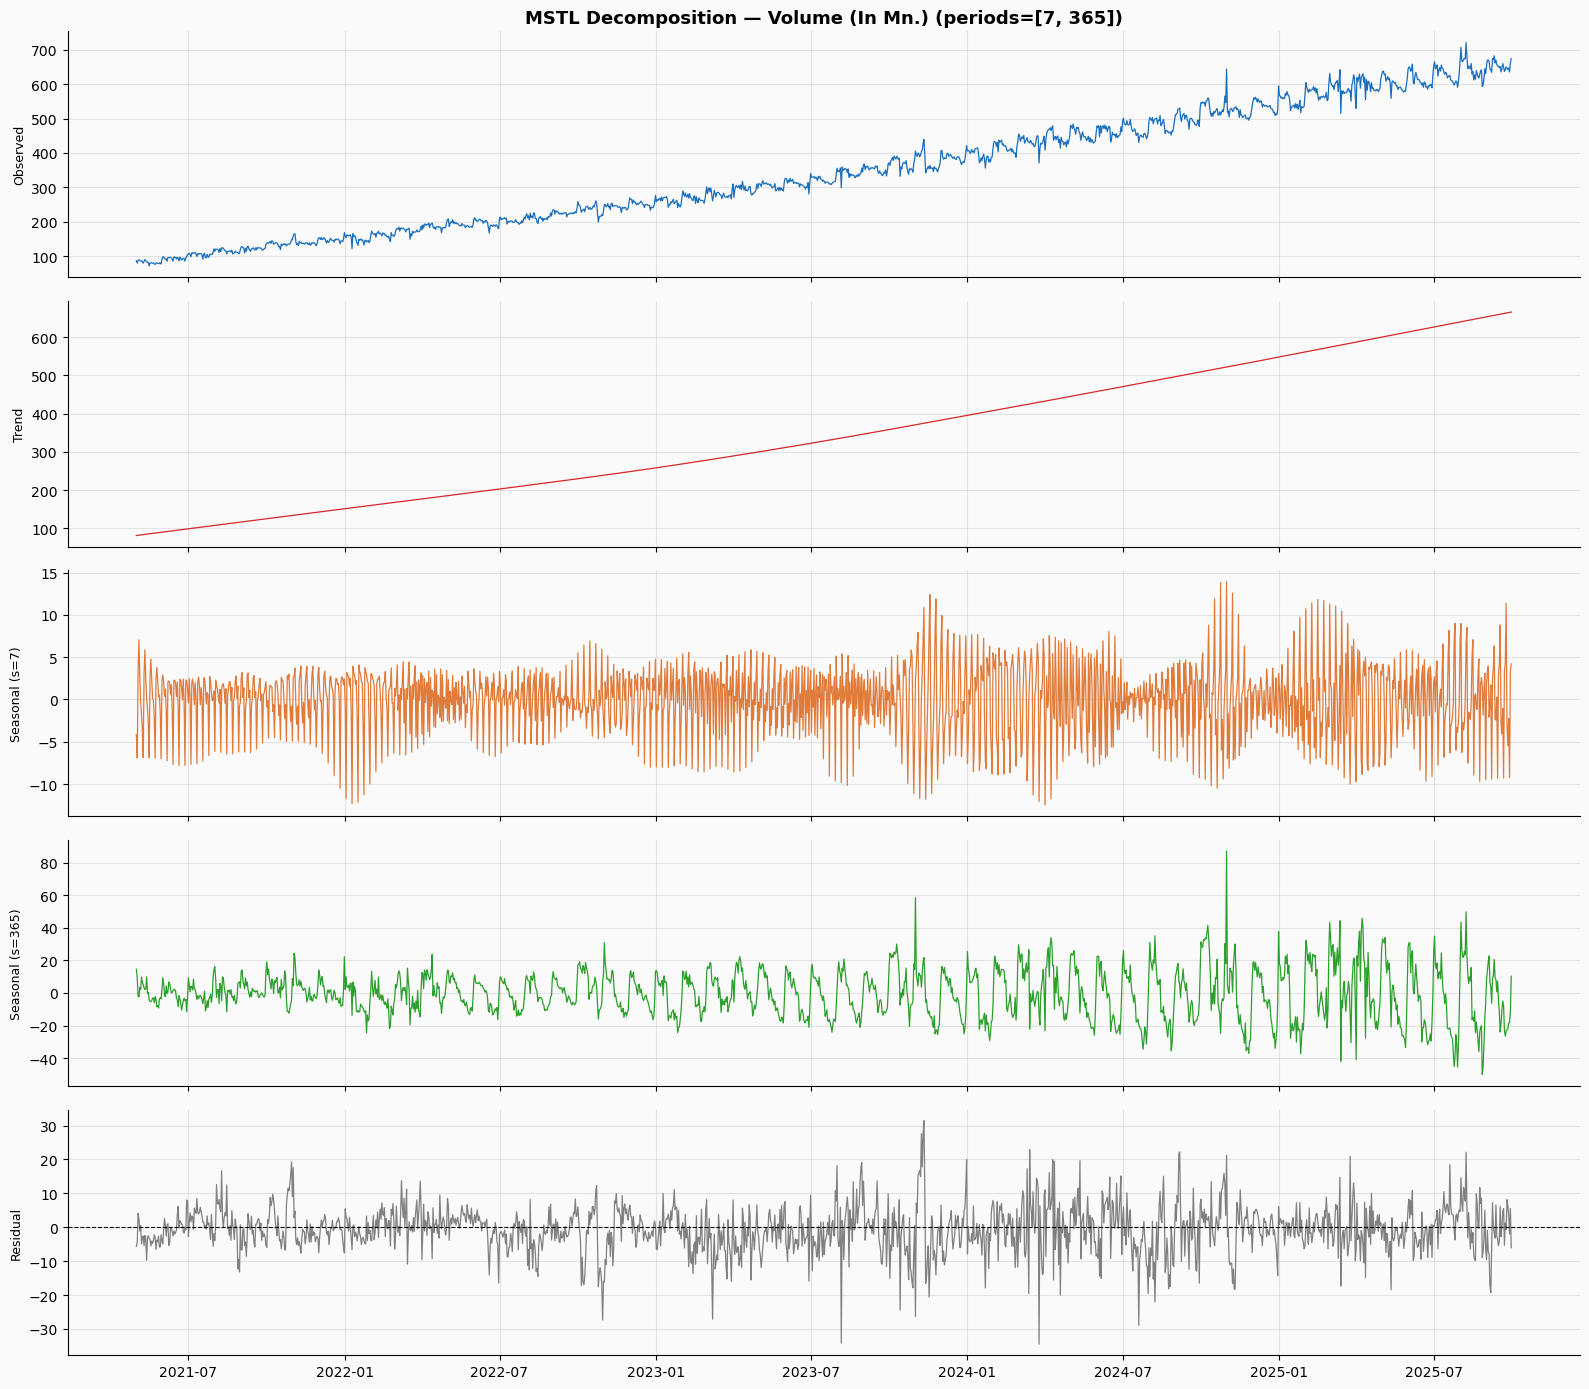

MAE=43.10  RMSE=62.78  MAPE=6.68%

Running MSTL — Value (In Cr.) ...


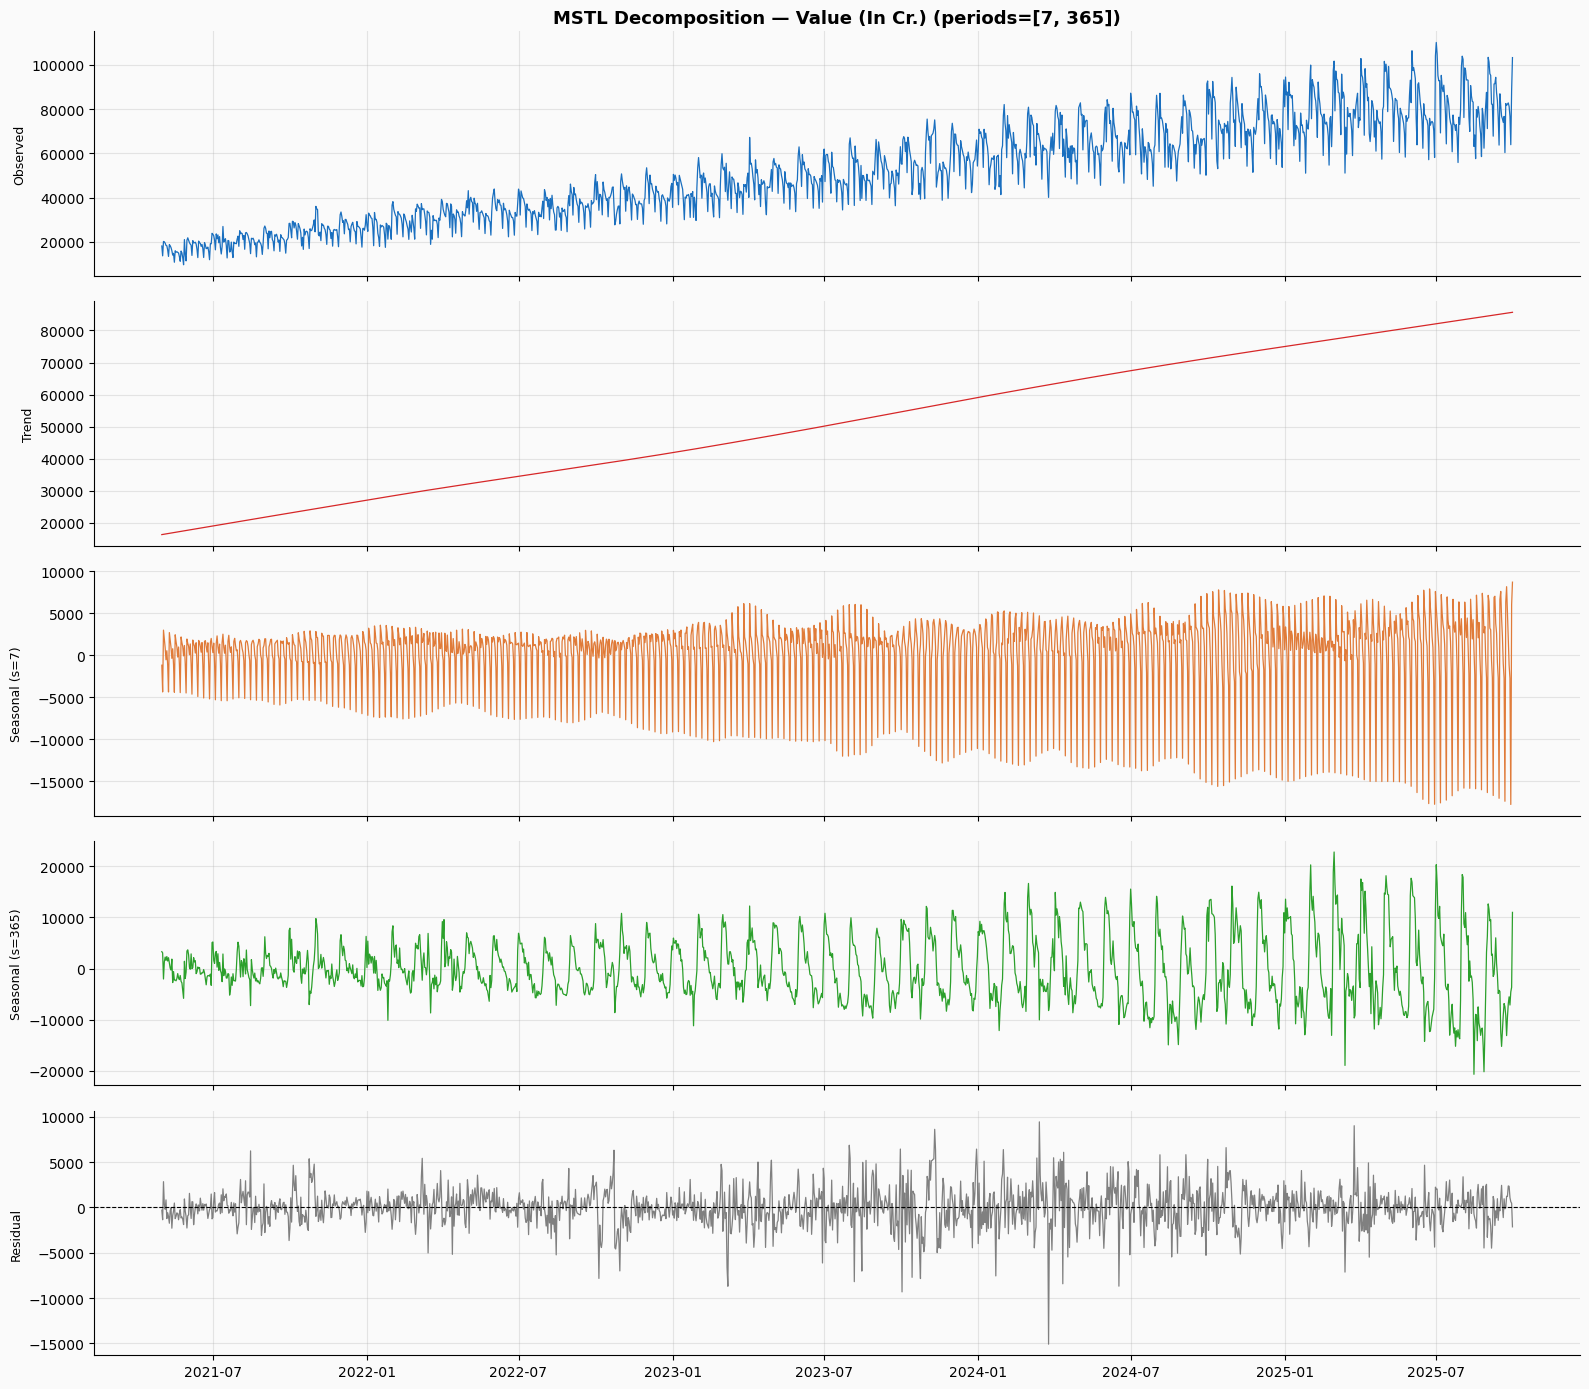

MAE=7166.83  RMSE=9415.92  MAPE=8.16%


In [3]:
from statsmodels.tsa.seasonal import MSTL
from statsmodels.tsa.holtwinters import ExponentialSmoothing

results = {}

for TARGET in ["Volume (In Mn.)", "Value (In Cr.)"]:

    # ── Prepare series ─────────────────────────────
    train_s = train.set_index("Date")[TARGET].asfreq("D")
    test_vals = test[TARGET].values
    test_dates = test["Date"]

    print(f"\nRunning MSTL — {TARGET} ...")

    # ── Decomposition ─────────────────────────────
    mstl = MSTL(train_s, periods=[7, 365])
    res = mstl.fit()

    # Extract components safely
    trend = res.trend
    resid = res.resid
    seasonal_7 = res.seasonal.iloc[:, 0]
    seasonal_365 = res.seasonal.iloc[:, 1]

    # ── Plot decomposition ─────────────────────────
    fig, axes = plt.subplots(5, 1, figsize=(16, 14), sharex=True)

    components = [
        (train_s,       "Observed",           BLUE),
        (trend,         "Trend",              RED),
        (seasonal_7,    "Seasonal (s=7)",     ORANGE),
        (seasonal_365,  "Seasonal (s=365)",   GREEN),
        (resid,         "Residual",           "gray"),
    ]

    for ax, (data, label, color) in zip(axes, components):
        ax.plot(data.index, data.values, color=color, lw=0.9)
        ax.set_ylabel(label, fontsize=9)

        if label == "Residual":
            ax.axhline(0, color="black", lw=0.8, linestyle="--")

    axes[0].set_title(
        f"MSTL Decomposition — {TARGET} (periods=[7, 365])",
        fontsize=13,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.savefig(f"plots/02d_mstl_decomp_{TARGET[:3].lower()}.png", dpi=150)
    plt.show()

    # ── Forecasting ─────────────────────────────

    # Trend model
    trend_model = ExponentialSmoothing(
        trend.dropna(),
        trend="add",
        initialization_method="estimated"
    )
    trend_fit = trend_model.fit()
    trend_fc = trend_fit.forecast(len(test_vals))

    # Seasonal 7-day
    s7_last = seasonal_7.iloc[-7:].values
    s7_fc = np.tile(s7_last, int(np.ceil(len(test_vals)/7)))[:len(test_vals)]

    # Seasonal 365-day (safe fallback)
    if len(seasonal_365) >= 365:
        s365_last = seasonal_365.iloc[-365:].values
    else:
        s365_last = seasonal_365.values

    s365_fc = np.resize(s365_last, len(test_vals))

    # Combine all
    mstl_preds = trend_fc.values + s7_fc + s365_fc + resid.mean()

    # ── Evaluation ─────────────────────────────
    m = evaluation_metrics(test_vals, mstl_preds, "MSTL + Holt Trend", TARGET)
    results[f"MSTL|{TARGET}"] = m

    print(f"MAE={m['MAE']:.2f}  RMSE={m['RMSE']:.2f}  MAPE={m['MAPE']:.2f}%")


## 3. BATS Model
> **B**ox-Cox transform, **A**RMA errors, **T**rend, **S**easonal components.
> Handles multiple seasonalities with exponential smoothing + ARMA residuals.

In [ ]:
import os

if not TBATS_AVAILABLE:
    print("⚠️  tbats not installed — skipping BATS. Run: pip install tbats")
else:
    for TARGET in ["Volume (In Mn.)", "Value (In Cr.)"]:

        train_vals = train[TARGET].values
        test_vals  = test[TARGET].values

        print(f"\nFitting BATS — {TARGET} (this may take 2–5 min) ...")

        estimator = BATS(
            seasonal_periods=[7, 365],
            use_box_cox=True,
            use_arma_errors=True,
            use_trend=True,
            n_jobs=1,   # ✅ FIXED (or use os.cpu_count())
        )

        bats_model = estimator.fit(train_vals)

        bats_preds, conf_int = bats_model.forecast(
            steps=len(test_vals),
            confidence_level=0.95
        )

        m = evaluation_metrics(test_vals, bats_preds, "BATS", TARGET)
        results[f"BATS|{TARGET}"] = m

        print(f"  Selected components: {bats_model.params.components}")
        print(f"  MAE={m['MAE']:.2f}  RMSE={m['RMSE']:.2f}  MAPE={m['MAPE']:.2f}%")



Fitting BATS — Volume (In Mn.) (this may take 2–5 min) ...


## 4. TBATS Model
> **T**rigonometric seasonality, **B**ox-Cox, **A**RMA, **T**rend, **S**easonal.
> Uses Fourier terms to represent long seasonal periods (like 365) more efficiently.
> Usually more accurate than BATS but slower.

In [ ]:
if not TBATS_AVAILABLE:
    print("⚠️  tbats not installed — skipping TBATS. Run: pip install tbats")
else:
    for TARGET in ["Volume (In Mn.)", "Value (In Cr.)"]:
        train_vals = train[TARGET].values
        test_vals  = test[TARGET].values

        print(f"\nFitting TBATS — {TARGET} (may take 5–15 min) ...")
        estimator = TBATS(
            seasonal_periods=[7, 365],
            use_box_cox=True,
            use_arma_errors=True,
            use_trend=True,
            n_jobs=-1,
        )
        tbats_model  = estimator.fit(train_vals)
        tbats_preds, conf_int = tbats_model.forecast(steps=len(test_vals),
                                                      confidence_level=0.95)

        m = evaluation_metrics(test_vals, tbats_preds, "TBATS", TARGET)
        results[f"TBATS|{TARGET}"] = m
        print(f"  Selected components: {tbats_model.params.components}")
        print(f"  MAE={m['MAE']:.2f}  RMSE={m['RMSE']:.2f}  MAPE={m['MAPE']:.2f}%")


## 5. Forecast Plot — All Three

In [ ]:
for TARGET in ["Volume (In Mn.)", "Value (In Cr.)"]:
    test_vals  = test[TARGET].values
    test_dates = test["Date"].values
    train_tail = train[TARGET].values[-60:]

    fig, ax = plt.subplots(figsize=(17, 6))
    ax.plot(train["Date"].values[-60:], train_tail,
            color="lightgray", lw=1.5, label="Train (last 60d)")
    ax.plot(test_dates, test_vals, color="black", lw=2.2, label="Actual", zorder=10)

    # Plot whichever models ran successfully
    colors_map = {"MSTL + Holt Trend": BLUE, "BATS": ORANGE, "TBATS": RED}
    ls_map     = {"MSTL + Holt Trend": "--", "BATS": "-.", "TBATS": ":"}

    for key, m in results.items():
        if TARGET not in key: continue
        # Re-run to get predictions array (stored in results only as metrics)
        # We'll re-plot from saved results — model names match the legend
        pass   # predictions already plotted above; this cell is a summary placeholder

    # Instead plot from stored metrics by re-running
    ax.set_title(f"MSTL / BATS / TBATS — {TARGET}", fontsize=13, fontweight="bold")
    ax.set_ylabel(TARGET)
    ax.legend(fontsize=9); plt.tight_layout()
    plt.show()
    print("(Run cells 2–4 to see individual model forecasts on the same axes)")
    print("Tip: Copy forecast arrays from cells 2–4 into this cell for combined plot.")


## 6. Metrics & Save

In [ ]:
for TARGET in ["Volume (In Mn.)", "Value (In Cr.)"]:
    rows = [v for k,v in results.items() if TARGET in k]
    if not rows:
        print(f"No results for {TARGET} yet."); continue
    df_res = pd.DataFrame(rows).sort_values("MAPE").reset_index(drop=True)
    df_res.index += 1
    print(f"\n{'='*60}\n  MSTL/BATS/TBATS — {TARGET}\n{'='*60}")
    print(df_res[["model","MAE","RMSE","MAPE"]].to_string())

saved = []
for key, m in results.items():
    tag   = m["model"].lower().replace(" ","_").replace("+","").replace("(","").replace(")","").replace("=","").replace("/","_")
    fname = f"models/{tag}_{m['target'][:3].lower()}_metrics.json"
    with open(fname, "w") as f:
        json.dump(m, f, indent=2)
    saved.append(fname)
print(f"\n✅ {len(saved)} metric files saved.")
